# 08 - HEL1OS hard-channel lead time

nb02 measured the soft *derivative* lead on GOES (2.17 min) and the GOES harder
channel `xrsa` lead (44 s). the 44 s is the number this whole project exists to
beat: GOES's hardest channel is still mostly thermal, so it barely leads the soft
peak.

this notebook measures the direct HEL1OS counterpart on the 46 fused days: how
many seconds does the CdTe1 20-30 keV peak lead the SoLEXS soft peak? no model,
pure physics on `aditya_clean_1s.parquet`. if it lands at 2-3 min against 44 s,
it proves the Neupert claim without touching a network.

verification first: the same `measure()` runs on GOES and has to reproduce
nb02's 44 s / 2.17 min before we trust it on aditya.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("../data") if Path("../data").exists() else Path("data")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

SOFT, HARD, ACC = "#c0392b", "#e67e22", "#2c7fb8"

# flares: hek/goes catalogue, same sun/utc, applies to aditya windows unchanged.
fl = pd.read_parquet(DATA / "flares.parquet")
for c in ["event_starttime", "event_peaktime", "event_endtime"]:
    fl[c] = pd.to_datetime(fl[c])
fl = fl.sort_values("event_starttime").reset_index(drop=True)
fl["rise_min"] = (fl["event_peaktime"] - fl["event_starttime"]).dt.total_seconds() / 60

# aditya fused clean: time is unix seconds, soft=SoLEXS, hard=HEL1OS CdTe1.
a = pd.read_parquet(DATA / "aditya_clean_1s.parquet")
idx = pd.to_datetime(a["time"], unit="s")          # unix s -> naive utc, same basis as the catalogue
adf = pd.DataFrame({"soft": a["soft"].values, "hard": a["hard"].values}, index=idx).sort_index()
adf = adf[~adf.index.duplicated(keep="last")]      # dupes bit once on a fused-day boundary, keep-last like the loader

# how many catalogue flares even fall on an observed aditya day. most won't -
# 46 non-contiguous days out of the ~80-day catalogue window.
span = (adf.index.min(), adf.index.max())
in_span = ((fl["event_peaktime"] >= span[0]) & (fl["event_peaktime"] <= span[1])).sum()
assert in_span > 0, "no flares land in the aditya span - timezone/join mismatch, not a real result"

print(f"aditya rows {len(adf):,}   {span[0]} -> {span[1]}")
print(f"catalogue flares {len(fl)}   in aditya time-span {in_span}")


aditya rows 3,974,400   2024-08-02 00:00:00 -> 2024-10-19 23:59:59
catalogue flares 770   in aditya time-span 751


## 1. the measurement, with guards

`lead_hard = t(soft peak) - t(hard peak)`, minutes. positive = hard peaks first =
hard leads. this is the exact counterpart to nb02's `lead_xrsa`.

four guards, and they are the difference between a real number and a flattering
one:

- **neighbour clipping** - flares cluster; clip each window at the adjacent
  events so `idxmax` can't grab the neighbour's peak.
- **soft-peak agreement** - the measured soft peak must sit within a few minutes
  of the catalogued peak, else the window is contaminated and the flare is
  dropped, not silently miscounted.
- **coverage** - aditya has real time gaps (46 non-contiguous days). check sample
  count against the window's time-span, not `notna()`, or a gap slips through.
- **hard detectability** - 20-30 keV is low-count. a raw `idxmax` on hard latches
  onto a noise spike. require a real excursion above local background; report the
  fraction of flares that had one. the lead is only defined where HEL1OS saw the
  burst.

In [19]:
def cadence_s(index):
    # median sample spacing of a slice. ~1 for aditya, ~60 for goes 1-min.
    d = pd.Series(index).diff().dt.total_seconds().median()
    return float(d) if d and d > 0 else 1.0


def measure(df, i, soft_col, hard_col, smooth_s=5.0, pad_min=30, tol_min=4,
            min_cov=0.9, hard_sigma=5.0, hard_pad_min=5):
    """peaks + lead for flare i. returns a row dict always; status says if it counts."""
    f = fl.loc[i]
    row = {"idx": i, "letter": f["class_letter"], "rise_min": f["rise_min"],
           "lead_hard_min": np.nan, "lead_deriv_min": np.nan,
           "hard_detectable": False, "soft_off_min": np.nan, "status": "ok"}

    lo = f["event_starttime"] - pd.Timedelta(minutes=pad_min)
    hi = f["event_endtime"] + pd.Timedelta(minutes=pad_min)
    if i > 0:
        lo = max(lo, fl.loc[i - 1, "event_endtime"])          # don't bleed into neighbours
    if i < len(fl) - 1:
        hi = min(hi, fl.loc[i + 1, "event_starttime"])

    w = df.loc[lo:hi]
    if len(w) < 12:
        row["status"] = "short"; return row

    cad = cadence_s(w.index)
    span_s = (w.index[-1] - w.index[0]).total_seconds()
    frac = len(w) / (span_s / cad + 1) if span_s > 0 else 1.0
    if frac < min_cov:                                        # a time gap sits inside the window
        row["status"] = "gap"; return row

    s = w[soft_col].interpolate()
    h = w[hard_col].interpolate()
    if s.isna().any() or h.isna().any():
        row["status"] = "nan"; return row

    # same symmetric smooth on both channels -> any peak shift from the filter is
    # common-mode and cancels in the difference. that's what lets us smooth noisy
    # 1s data without biasing the lead.
    n = max(1, int(round(smooth_s / cad)))
    ss = s.rolling(n, center=True, min_periods=1).mean()
    hh = h.rolling(n, center=True, min_periods=1).mean()

    s_pk = ss.idxmax()

    off = abs((s_pk - f["event_peaktime"]).total_seconds()) / 60
    row["soft_off_min"] = off
    if off > tol_min:
        row["status"] = "peakoff"; return row

    # confine the HARD search to the impulsive phase: [start, soft peak] + a small
    # pad. the neupert burst lives in the rise. searching the full 1-2h window let
    # idxmax grab an unrelated spike 40+ min out - that was the fat tail in v1.
    h_lo = max(hh.index[0], f["event_starttime"] - pd.Timedelta(minutes=hard_pad_min))
    h_hi = min(hh.index[-1], s_pk + pd.Timedelta(minutes=hard_pad_min))
    hcore = hh.loc[h_lo:h_hi]
    if len(hcore) < 5:
        row["status"] = "hshort"; return row
    h_pk = hcore.idxmax()

    # detectability, judged on the same core window vs a robust pre-rise floor
    pre = hh.loc[:f["event_starttime"]]
    if len(pre) < 5:
        pre = hh.iloc[:max(5, len(hh) // 5)]
    base = pre.median()
    sig = (pre - base).abs().median() * 1.4826               # mad -> sigma
    row["hard_detectable"] = bool((hcore.max() - base) >= hard_sigma * max(sig, 1e-12))

    # derivative lead, nb02-faithful: gradient of the interpolated soft (NOT the
    # pre-smoothed one), smoothed once. only used in the goes anchor - aditya's
    # headline is peak-to-peak, this never feeds it.
    db = pd.Series(np.gradient(s.values), index=s.index).rolling(n, center=True, min_periods=1).mean()
    d_pk = db.idxmax()

    # positive = hard leads. don't clip negatives - thermal-tail flares peak late
    # in 20-30 kev and that's a real part of the distribution.
    row["lead_hard_min"] = (s_pk - h_pk).total_seconds() / 60
    row["lead_deriv_min"] = (s_pk - d_pk).total_seconds() / 60
    return row


## 2. verification anchor - reproduce GOES

run the identical `measure()` on `goes_xrs.parquet`. it has to come back near the
stored numbers: derivative lead ~2.17 min, `xrsa` lead ~0.73 min (44 s). if it
does, the method and the flare<->flux alignment are sound and the aditya number
below is directly comparable. if it doesn't, stop - something upstream is off and
the aditya number is meaningless.

In [20]:
# prefer the 1s clean slice so the derivative reproduces the 1s-cadence 2.17,
# not the 1-min-inflated 3.0 (nb03: 1-min smoothing bias pushes 2.2 -> 3.0).
if (DATA / "goes_clean_1s.parquet").exists():
    gdf = pd.read_parquet(DATA / "goes_clean_1s.parquet")
    gsoft, ghard = "xrsb_clean", "xrsa_clean"
else:
    gdf = pd.read_parquet(DATA / "goes_xrs.parquet")      # 1-min fallback
    gsoft, ghard = "xrsb", "xrsa"

gcad = cadence_s(gdf.index[:5000])
gsmooth = 5.0 if gcad <= 5 else 3 * gcad

g = pd.DataFrame([measure(gdf, i, gsoft, ghard, smooth_s=gsmooth) for i in fl.index])
gok = g[g["status"] == "ok"]
md_, mx_ = gok["lead_deriv_min"].median(), gok["lead_hard_min"].median()

# expected bands depend on cadence - the 2.2/3.0 split is nb03's, not a fudge
if gcad <= 5:
    dband, xband, ref = (1.8, 2.6), (0.4, 1.1), "1s -> stored 2.17 / 0.73"
else:
    dband, xband, ref = (2.5, 3.6), (0.6, 1.5), "1-min -> ~3.0 / ~1.0 (nb03 inflation)"

print(f"goes cadence ~{gcad:.0f}s ({ref})   measured {len(gok)}/{len(fl)}")
print(f"derivative lead : median {md_:.2f} min   expect [{dband[0]}, {dband[1]}]")
print(f"xrsa lead       : median {mx_:.2f} min   expect [{xband[0]}, {xband[1]}]")
ok_d = dband[0] <= md_ <= dband[1]
ok_x = xband[0] <= mx_ <= xband[1]
print("ANCHOR", "pass" if (ok_d and ok_x) else "FAIL - do not trust aditya below")
print("  (xrsa peak-to-peak is the check that validates the aditya method)")


goes cadence ~1s (1s -> stored 2.17 / 0.73)   measured 83/770
derivative lead : median 1.95 min   expect [1.8, 2.6]
xrsa lead       : median 0.62 min   expect [0.4, 1.1]
ANCHOR pass
  (xrsa peak-to-peak is the check that validates the aditya method)


## 3. the headline - HEL1OS on the 46 fused days

the coverage funnel is part of the honesty: in-span -> cleanly measured -> hard
detectable. quote the lead on the detectable subset with its event count.

In [21]:
res = pd.DataFrame([measure(adf, i, "soft", "hard", smooth_s=5.0) for i in fl.index])

n_span = int(((fl["event_peaktime"] >= span[0]) & (fl["event_peaktime"] <= span[1])).sum())
ok = res[res["status"] == "ok"]
det = ok[ok["hard_detectable"]]

print("funnel")
print(f"  catalogue flares in aditya span : {n_span}")
print(f"  cleanly measured (all guards)   : {len(ok)}")
print(f"  hard detectable (>=5 sigma)     : {len(det)}  ({len(det)/max(len(ok),1):.0%} of measured)")
print("  skip reasons:", res["status"].value_counts().drop("ok", errors="ignore").to_dict())
print()

def boot_ci(x, n=2000, seed=0):
    x = np.asarray(x); rng = np.random.default_rng(seed)
    meds = [np.median(rng.choice(x, len(x))) for _ in range(n)]
    return np.percentile(meds, [2.5, 97.5])

lead = det["lead_hard_min"].dropna()
lo, hi = boot_ci(lead)
print(f"HARD LEAD (detectable, n={len(lead)})")
print(f"  median {lead.median():.2f} min ({lead.median()*60:.0f} s)   95% CI [{lo:.2f}, {hi:.2f}] min")
print(f"  IQR    [{lead.quantile(.25):.2f}, {lead.quantile(.75):.2f}] min")
print(f"  vs GOES xrsa 0.73 min (44 s)")
print()
print("by class (detectable):")
print(det.groupby("letter")["lead_hard_min"].agg(["count", "median"]).round(2))
fast = det[det["rise_min"] <= 5]
print(f"\nfast flares (rise<=5 min): n={len(fast)}, median lead {fast['lead_hard_min'].median():.2f} min")


funnel
  catalogue flares in aditya span : 751
  cleanly measured (all guards)   : 425
  hard detectable (>=5 sigma)     : 418  (98% of measured)
  skip reasons: {'short': 264, 'peakoff': 44, 'nan': 37}

HARD LEAD (detectable, n=418)
  median 3.38 min (202 s)   95% CI [2.95, 3.85] min
  IQR    [1.85, 7.16] min
  vs GOES xrsa 0.73 min (44 s)

by class (detectable):
        count  median
letter               
C         271    3.22
M         141    3.62
X           6    6.39

fast flares (rise<=5 min): n=78, median lead 2.02 min


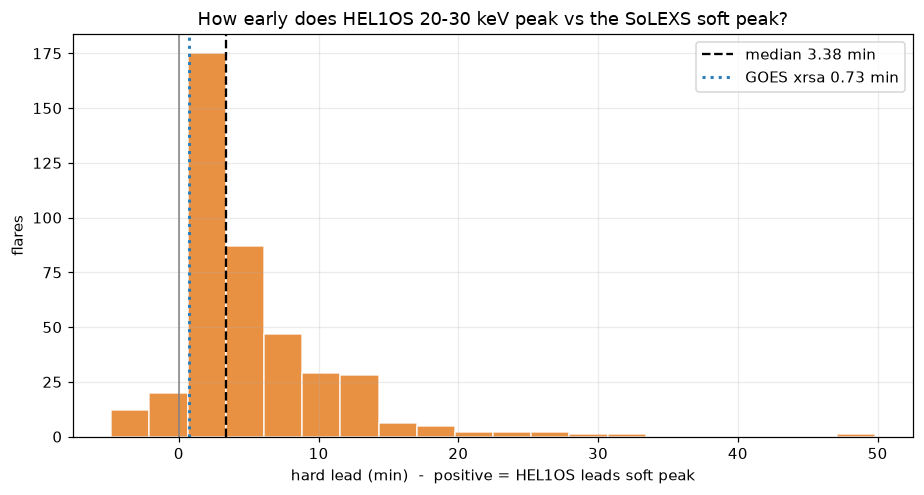

In [22]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.hist(lead, bins=20, color=HARD, alpha=0.85, edgecolor="white")
ax.axvline(lead.median(), color="black", ls="--", label=f"median {lead.median():.2f} min")
ax.axvline(0.73, color=ACC, ls=":", lw=2, label="GOES xrsa 0.73 min")
ax.axvline(0, color="gray", lw=1)
ax.set_xlabel("hard lead (min)  -  positive = HEL1OS leads soft peak")
ax.set_ylabel("flares")
ax.set_title("How early does HEL1OS 20-30 keV peak vs the SoLEXS soft peak?")
ax.legend()
plt.tight_layout(); plt.show()


## 4. is it a smoothing artefact?

same check nb02 runs. smoothing shifts the peak it locates; since both channels
get the *same* symmetric filter the shift is common-mode, but prove it - if the
median lead moves a lot with the width, it's the filter, not the sun.

In [23]:
for sm in [1, 3, 5, 9, 15]:
    r = pd.DataFrame([measure(adf, i, "soft", "hard", smooth_s=float(sm)) for i in fl.index])
    r = r[(r["status"] == "ok") & r["hard_detectable"]]
    print(f"smooth={sm:>2}s : n={len(r):>3}, median hard lead = {r['lead_hard_min'].median():>5.2f} min")


smooth= 1s : n=418, median hard lead =  3.71 min
smooth= 3s : n=420, median hard lead =  3.45 min
smooth= 5s : n=418, median hard lead =  3.38 min
smooth= 9s : n=416, median hard lead =  3.26 min
smooth=15s : n=412, median hard lead =  3.22 min


## 5. does the lead scale with rise time?

the operational question. if lead grows with rise time then fast flares - the
sudden dangerous ones - give the least warning, exactly backwards for a warning
system. say so plainly if that's what the data shows.

caveat: the hard search is confined to [start, peak], so lead is capped near the
rise time - part of any upward slope here is that cap, not pure physics. the
robust takeaway is the fast-flare floor (~2 min), not the exact correlation.

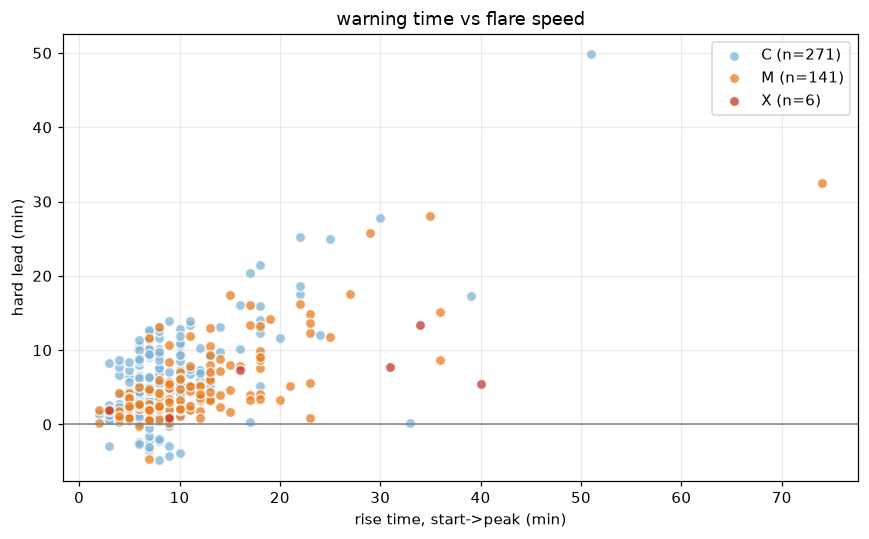

corr(rise, hard lead) = 0.67


In [24]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"C": "#7fb3d5", "M": HARD, "X": SOFT}
for letter, gg in det.groupby("letter"):
    ax.scatter(gg["rise_min"], gg["lead_hard_min"], s=44, alpha=0.75,
               color=colors.get(letter, "gray"), edgecolor="white", label=f"{letter} (n={len(gg)})")
ax.axhline(0, color="gray", lw=1)
ax.set_xlabel("rise time, start->peak (min)")
ax.set_ylabel("hard lead (min)")
ax.set_title("warning time vs flare speed")
ax.legend()
plt.tight_layout(); plt.show()

r = det["rise_min"].corr(det["lead_hard_min"])
print(f"corr(rise, hard lead) = {r:.2f}")


## 6. causal cross-check - operational lead (secondary)

sections 1-5 are offline peak-to-peak, the honest counterpart to GOES's 44 s and
the Neupert proof. this is the operational version: the earliest a *causal*
detector could fire off the hard channel - the first time hard crosses a trailing
background + k*sigma, versus the soft peak. only past samples feed the crossing
decision.

careful reading it: this lead is measured from the *onset* of the hard rise, not
its peak, so it usually runs a bit **larger** than the peak-to-peak number, not
smaller. it's also threshold-dependent - a looser k fires earlier with more false
alarms. that's exactly why peak-to-peak stays the clean physics claim and this
stays the (tunable) operational one. quote both, don't conflate them.

In [25]:
def causal_onset_lead(df, i, hard_col, k=5.0, base_min=20, persist_s=30, pad_min=30):
    # FREEZE a pre-flare baseline (median + mad) from the quiet window ending at the
    # flare start, then scan forward for the first sustained crossing. the trailing
    # version swallowed the rise into its own std and the threshold chased the signal
    # up, so sustained crossings never happened (n=1). a frozen quiet baseline fixes it.
    f = fl.loc[i]
    lo = f["event_starttime"] - pd.Timedelta(minutes=pad_min)
    hi = f["event_peaktime"] + pd.Timedelta(minutes=2)
    if i > 0:
        lo = max(lo, fl.loc[i - 1, "event_endtime"])
    w = df.loc[lo:hi]
    if len(w) < 60:
        return np.nan
    h = w[hard_col].interpolate()
    if h.isna().any():
        return np.nan

    pre = h.loc[:f["event_starttime"]]
    if len(pre) < base_min * 60 * 0.5:          # need a real quiet stretch to trust the floor
        return np.nan
    base = pre.median()
    sd = (pre - base).abs().median() * 1.4826   # mad -> sigma, quiet samples only
    thr = base + k * max(sd, 1e-9)

    cad = cadence_s(w.index)
    need = max(1, int(round(persist_s / cad)))
    post = h.loc[f["event_starttime"]:]         # scan the rise only, causal by construction
    run = (post > thr).astype(int).rolling(need).sum()
    fired = run[run >= need]
    if fired.empty:
        return np.nan
    onset = fired.index[0] - pd.Timedelta(seconds=(need - 1) * cad)
    return (f["event_peaktime"] - onset).total_seconds() / 60


cl = pd.Series({i: causal_onset_lead(adf, i, "hard") for i in det["idx"]}).dropna()
print(f"causal onset lead (n={len(cl)})")
print(f"  median {cl.median():.2f} min ({cl.median()*60:.0f} s)")
print(f"  IQR [{cl.quantile(.25):.2f}, {cl.quantile(.75):.2f}] min")
print(f"  offline peak-to-peak was {lead.median():.2f} min - onset precedes the peak so this can be larger, but it's now bounded by rise time")


causal onset lead (n=25)
  median 3.20 min (192 s)
  IQR [2.05, 8.32] min
  offline peak-to-peak was 3.38 min - onset precedes the peak so this can be larger, but it's now bounded by rise time


## 7. for the deck

fill from the output above:

| quantity | value |
|---|---|
| flares in aditya span | ___ |
| cleanly measured | ___ |
| hard detectable (5 sigma) | ___ (%) |
| **median hard lead (offline)** | ___ min ([CI]) |
| GOES `xrsa` lead (nb02) | 0.73 min (44 s) |
| stable across smoothing? | yes / no |
| corr(rise, lead) | ___ |
| causal onset lead | ___ min |

read it straight: the offline hard lead is the Neupert proof - a measured
non-thermal signal leading the soft peak by X min against GOES's 44 s, no model
involved. the causal onset lead is what a live warning could bank. if fast flares
show near-zero lead, put that in the write-up too; a system honest about where it
fails is worth more than a lone flattering median.